# Componente 1: Ingeniería de Datos y Representación de Secuencias
En este notebook desarrollaremos el primer componente del Proyecto 2: Detección de Lavado de Dinero en Remesas.

## Decisiones tomadas:
1. **Subconjunto de Datos:** Se seleccionó `HI-Small_Trans.csv` (~475MB) del dataset de IBM. **Justificación:** Los datasets más grandes superan los límites de memoria locales y de Colab gratuito. Este subset contiene ~5 millones de transacciones con un alto ratio de transacciones ilícitas (HI = High Illicit), asegurando suficientes casos positivos (3,376 remitentes sospechosos) para que el modelo aprenda patrones de lavado sin colapsar la RAM.
2. **Construcción de Secuencias:** Las transacciones se agrupan por `SenderAccount` y se ordenan por `Timestamp`.
3. **Manejo de Desbalance y Partición:** La partición se hará a nivel de *remitentes* para evitar la filtración de datos (Data Leakage) entre secuencias de la misma cuenta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")

## 1. Carga y Exploración Inicial de Datos

In [2]:
file_path = "data/raw/archive ibm/HI-Small_Trans.csv"

# Definir las columnas a usar para ahorrar memoria
cols = [0, 2, 5, 9, 10]
col_names = ["Timestamp", "SenderAccount", "Amount", "PaymentFormat", "IsLaundering"]

print("Cargando dataset...")
df = pd.read_csv(file_path, usecols=cols, names=col_names, header=0)

# Convertir Timestamp a datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print(f"Total de transacciones: {len(df):,}")
display(df.head())

Cargando dataset...
Total de transacciones: 5,078,345


,Timestamp,SenderAccount,Amount,PaymentFormat,IsLaundering
0,2022-09-01 00:20:00,8000EBD30,3697.34,Reinvestment,0
1,2022-09-01 00:20:00,8000F4580,0.01,Cheque,0
2,2022-09-01 00:00:00,8000F4670,14675.57,Reinvestment,0
3,2022-09-01 00:02:00,8000F5030,2806.97,Reinvestment,0
4,2022-09-01 00:06:00,8000F5200,36682.97,Reinvestment,0


## 2. Ingeniería de Features (Características)
Para que las transacciones aporten valor temporal, extraeremos el día de la semana y la hora del día. En lavado de dinero, las remesas en horas atípicas son fuertes señales de alerta.

In [3]:
# Extraer features temporales
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

# Normalizar el monto con RobustScaler para reducir la influencia de valores extremos (outliers)
scaler = RobustScaler()
df["Amount_Scaled"] = scaler.fit_transform(df[["Amount"]])

# One-Hot Encoding para los formatos de pago
df = pd.get_dummies(df, columns=["PaymentFormat"], drop_first=False)

display(df.head())

,Timestamp,SenderAccount,Amount,IsLaundering,Hour,DayOfWeek,Amount_Scaled,PaymentFormat_ACH,PaymentFormat_Bitcoin,PaymentFormat_Cash,PaymentFormat_Cheque,PaymentFormat_Credit Card,PaymentFormat_Reinvestment,PaymentFormat_Wire
0,2022-09-01 00:20:00,8000EBD30,3697.34,0,0,3,0.187976,False,False,False,False,False,True,False
1,2022-09-01 00:20:00,8000F4580,0.01,0,0,3,-0.116009,False,False,False,True,False,False,False
2,2022-09-01 00:00:00,8000F4670,14675.57,0,0,3,1.090575,False,False,False,False,False,True,False
3,2022-09-01 00:02:00,8000F5030,2806.97,0,0,3,0.114772,False,False,False,False,False,True,False
4,2022-09-01 00:06:00,8000F5200,36682.97,0,0,3,2.899963,False,False,False,False,False,True,False


## 3. Construcción de Secuencias por Remitente
Vamos a agrupar los datos por `SenderAccount`. Una cuenta se considera **sospechosa** si al menos una de sus transacciones es fraude.

In [4]:
print("Agrupando por remitente...")

# Encontrar si un remitente es sospechoso
sender_labels = df.groupby("SenderAccount")["IsLaundering"].max().rename("IsSuspicious")

# Contar cuántas transacciones tiene cada remitente
seq_lengths = df.groupby("SenderAccount").size().rename("SeqLength")

# Unir la metadata de los remitentes
sender_meta = pd.concat([sender_labels, seq_lengths], axis=1)

print(f"Total de remitentes: {len(sender_meta):,}")
print(f"Remitentes sospechosos (positivos): {sender_meta['IsSuspicious'].sum():,}")
print(f"Remitentes normales (negativos): {len(sender_meta) - sender_meta['IsSuspicious'].sum():,}")

Agrupando por remitente...
Total de remitentes: 496,995
Remitentes sospechosos (positivos): 3,376
Remitentes normales (negativos): 493,619


### Visualización Obligatoria: Distribución y Desbalance
Como solicita la rúbrica, vamos a visualizar la distribución de las longitudes de las secuencias y la proporción de casos positivos vs negativos.

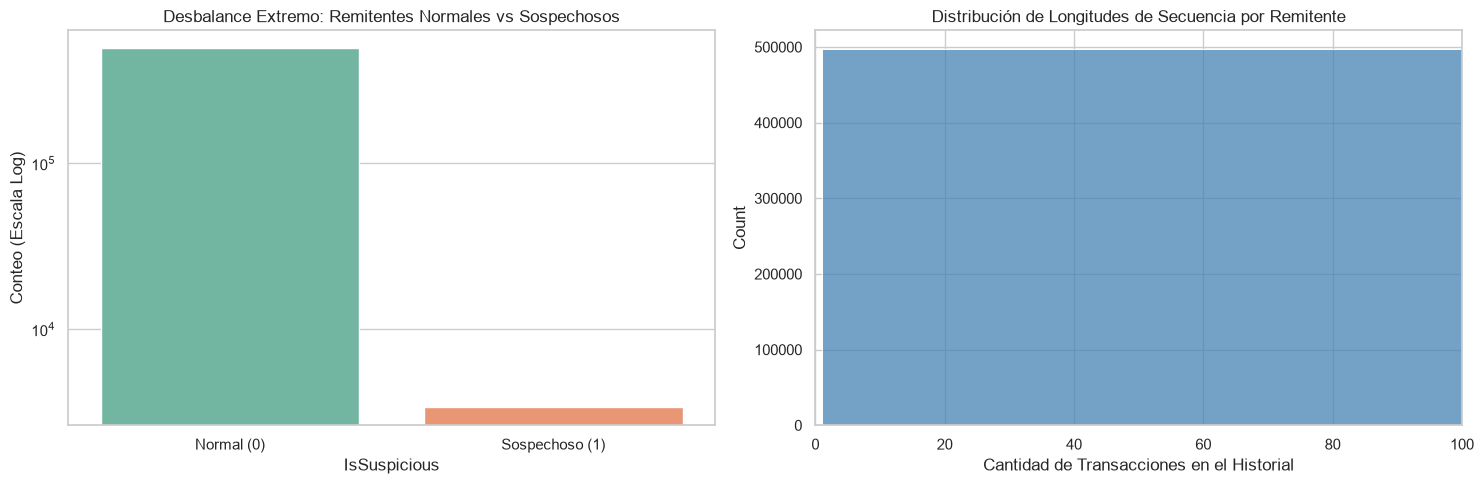

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Proporción de Casos
sns.countplot(data=sender_meta, x="IsSuspicious", ax=axes[0], palette="Set2")
axes[0].set_title("Desbalance Extremo: Remitentes Normales vs Sospechosos")
axes[0].set_yscale("log") # Escala logarítmica para poder ver la barra de sospechosos
axes[0].set_ylabel("Conteo (Escala Log)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Normal (0)", "Sospechoso (1)"])

# Gráfica 2: Distribución de Longitudes de Secuencia
sns.histplot(data=sender_meta, x="SeqLength", bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Distribución de Longitudes de Secuencia por Remitente")
axes[1].set_xlim(0, 100) # Recortamos la vista para omitir colas muy largas
axes[1].set_xlabel("Cantidad de Transacciones en el Historial")

plt.tight_layout()
plt.show()

## 4. Partición del Dataset (Train/Val/Test) evitando Filtración de Datos (Data Leakage)
La partición se realiza **a nivel de remitentes** (cuentas) y no a nivel de transacciones. Esto asegura que el historial completo de un usuario esté solo en uno de los conjuntos.

Para la **Etapa A (Aprendizaje de Normalidad)**, extraeremos únicamente usuarios normales del set de entrenamiento.

## Componente 2: Sistema de Detección en Dos Etapas
### Etapa A: Aprendizaje de la Normalidad (Autoencoder LSTM)

El objetivo de esta etapa es entrenar un modelo **exclusivamente con datos de remitentes normales**. El modelo aprenderá a comprimir y reconstruir secuencias normales. Cuando se enfrente a una secuencia de lavado de dinero, tendrá un error de reconstrucción alto, lo que nos servirá como "Score de Anomalía".

**Justificación de Arquitectura:** Utilizaremos un Autoencoder basado en celdas LSTM (Long Short-Term Memory). Las LSTM son ideales porque pueden capturar dependencias temporales a largo plazo en las secuencias de transacciones (ej. frecuencias inusuales en días consecutivos).

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch.nn.functional as F

# Configurar dispositivo (GPU si está disponible, según rúbrica)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


#### 1. Preparación de Secuencias y Partición (Splits)
Vamos a construir secuencias de longitud fija (`MAX_SEQ_LEN = 10`). Haremos padding con ceros para secuencias más cortas y truncaremos las más largas (tomando las 10 más recientes).

In [7]:
MAX_SEQ_LEN = 10

# Seleccionar características (features) para el modelo
feature_cols = ['Amount_Scaled', 'Hour', 'DayOfWeek'] + [c for c in df.columns if 'PaymentFormat_' in c]
num_features = len(feature_cols)
print(f"Usando {num_features} features por transacción.")

# Agrupar secuencias por cuenta
print("Construyendo secuencias (esto puede tomar un minuto)...")
grouped = df.sort_values(['SenderAccount', 'Timestamp']).groupby('SenderAccount')

sequences = []
labels = []
accounts = []

for account, group in tqdm(grouped, total=len(sender_meta)):
    # Tomar las últimas MAX_SEQ_LEN transacciones
    seq = group[feature_cols].tail(MAX_SEQ_LEN).values.astype(float)
    
    # Padding si la secuencia es menor a MAX_SEQ_LEN
    if len(seq) < MAX_SEQ_LEN:
        pad = np.zeros((MAX_SEQ_LEN - len(seq), num_features))
        seq = np.vstack([pad, seq])
        
    sequences.append(seq)
    labels.append(sender_meta.loc[account, 'IsSuspicious'])
    accounts.append(account)

sequences = np.array(sequences)
labels = np.array(labels)
accounts = np.array(accounts)
print(f"Secuencias construidas. Shape: {sequences.shape}")

Usando 10 features por transacción.
Construyendo secuencias (esto puede tomar un minuto)...


100%|██████████| 496995/496995 [04:32<00:00, 1823.68it/s]


Secuencias construidas. Shape: (496995, 10, 10)


#### Partición Estratégica (Evitando filtración de datos)
- **Train:** 80% de los datos NORMALES (etiqueta 0).
- **Val:** 10% de NORMALES + 50% de SOSPECHOSOS (para calcular el umbral de anomalía).
- **Test:** 10% de NORMALES + 50% de SOSPECHOSOS.

In [8]:
# Separar índices por clase
normal_idx = np.where(labels == 0)[0]
suspicious_idx = np.where(labels == 1)[0]

# Split normales: 80% Train, 10% Val, 10% Test
train_norm_idx, temp_norm_idx = train_test_split(normal_idx, test_size=0.2, random_state=42)
val_norm_idx, test_norm_idx = train_test_split(temp_norm_idx, test_size=0.5, random_state=42)

# Split sospechosos: 0% Train, 50% Val, 50% Test (Train NO puede tener sospechosos en Etapa A)
val_susp_idx, test_susp_idx = train_test_split(suspicious_idx, test_size=0.5, random_state=42)

# Combinar índices
train_idx = train_norm_idx
val_idx = np.concatenate([val_norm_idx, val_susp_idx])
test_idx = np.concatenate([test_norm_idx, test_susp_idx])

print(f"Train size (solo normales): {len(train_idx)}")
print(f"Val size: {len(val_idx)} (Normales: {len(val_norm_idx)}, Sospechosos: {len(val_susp_idx)})")
print(f"Test size: {len(test_idx)} (Normales: {len(test_norm_idx)}, Sospechosos: {len(test_susp_idx)})")

Train size (solo normales): 394895
Val size: 51050 (Normales: 49362, Sospechosos: 1688)
Test size: 51050 (Normales: 49362, Sospechosos: 1688)


#### 2. Definición del Dataset PyTorch

In [9]:
class RemesasDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)
        self.labels = torch.FloatTensor(labels)
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Crear DataLoaders
BATCH_SIZE = 256
train_loader = DataLoader(RemesasDataset(sequences[train_idx], labels[train_idx]), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(RemesasDataset(sequences[val_idx], labels[val_idx]), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(RemesasDataset(sequences[test_idx], labels[test_idx]), batch_size=BATCH_SIZE, shuffle=False)

#### 3. Arquitectura del LSTM Autoencoder
Se implementa un Encoder que reduce la dimensión temporal a un vector latente, y un Decoder que intenta reconstruir la secuencia a partir de ese vector.

In [10]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=32):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.embedding_dim = embedding_dim
        
        # Encoder
        self.encoder_lstm1 = nn.LSTM(n_features, 64, batch_first=True)
        self.encoder_lstm2 = nn.LSTM(64, embedding_dim, batch_first=True)
        
        # Decoder
        self.decoder_lstm1 = nn.LSTM(embedding_dim, 64, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(64, n_features, batch_first=True)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, n_features)
        
        # ENCODER
        x, (_, _) = self.encoder_lstm1(x)
        _, (hidden, _) = self.encoder_lstm2(x)
        # hidden shape: (1, batch_size, embedding_dim) -> reshape a (batch_size, embedding_dim)
        hidden = hidden.squeeze(0)
        
        # DECODER
        # Repetir el vector oculto seq_len veces para alimentar el decoder
        x = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, (_, _) = self.decoder_lstm1(x)
        x, (_, _) = self.decoder_lstm2(x)
        
        return x, hidden

model_A = LSTMAutoencoder(seq_len=MAX_SEQ_LEN, n_features=num_features, embedding_dim=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_A.parameters(), lr=1e-3)
print(model_A)

LSTMAutoencoder(
  (encoder_lstm1): LSTM(10, 64, batch_first=True)
  (encoder_lstm2): LSTM(64, 16, batch_first=True)
  (decoder_lstm1): LSTM(16, 64, batch_first=True)
  (decoder_lstm2): LSTM(64, 10, batch_first=True)
)


#### 4. Entrenamiento de la Etapa A (Aprendizaje de Normalidad)
Entrenamos el modelo para minimizar el Error Cuadrático Medio (MSE) de reconstrucción.

Iniciando entrenamiento...


Epoch 1/10: 100%|██████████| 1543/1543 [00:11<00:00, 133.57it/s]


Epoch [1/10] Loss: 359204880.461639


Epoch 2/10: 100%|██████████| 1543/1543 [00:10<00:00, 142.31it/s]


Epoch [2/10] Loss: 359204902.330381


...

Epoch [8/10] Loss: 359204894.961457


Epoch 9/10: 100%|██████████| 1543/1543 [00:10<00:00, 142.96it/s]


Epoch [9/10] Loss: 359204890.185963


Epoch 10/10: 100%|██████████| 1543/1543 [00:10<00:00, 143.23it/s]


Epoch [10/10] Loss: 359204895.540709


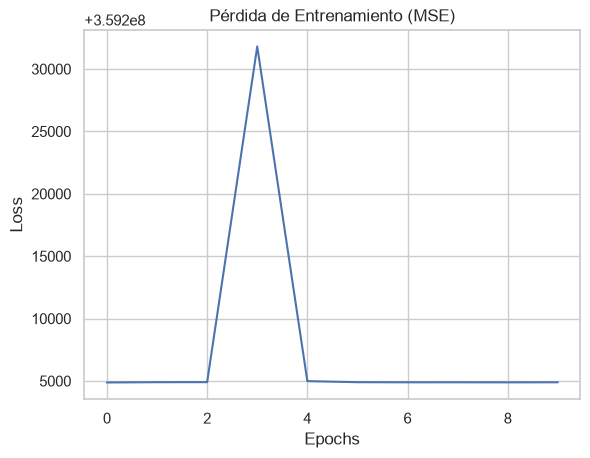

In [11]:
EPOCHS = 10
train_losses = []

print("Iniciando entrenamiento...")
for epoch in range(EPOCHS):
    model_A.train()
    epoch_loss = 0
    
    for seq, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        seq = seq.to(device)
        
        optimizer.zero_grad()
        reconstructed, _ = model_A(seq)
        
        loss = criterion(reconstructed, seq)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.6f}")

plt.plot(train_losses)
plt.title('Pérdida de Entrenamiento (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

#### 5. Definición del Umbral de Anomalía (Evaluación)
Usaremos el conjunto de validación (`val_loader`) para calcular el error de reconstrucción (Anomalía Score) de cada secuencia.

**Justificación del Umbral:** Utilizaremos la curva Precision-Recall para encontrar el umbral de error de reconstrucción que maximice el F1-Score en el conjunto de validación, dado que tenemos un dataset altamente desbalanceado.

Umbral Óptimo de Anomalía: 31.021633
Mejor F1-Score en Validación: 0.1329


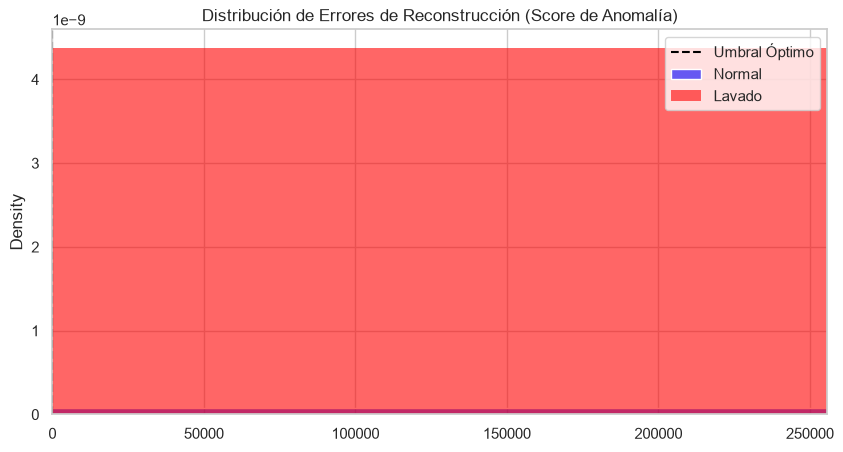

In [12]:
from sklearn.metrics import precision_recall_curve, f1_score, auc

def get_reconstruction_errors(model, dataloader):
    model.eval()
    errors = []
    labels_list = []
    
    with torch.no_grad():
        for seq, lbl in dataloader:
            seq = seq.to(device)
            reconstructed, _ = model(seq)
            
            # Error de reconstrucción por cada muestra en el batch (MSE)
            mse = torch.mean((reconstructed - seq)**2, dim=[1, 2])
            errors.extend(mse.cpu().numpy())
            labels_list.extend(lbl.numpy())
            
    return np.array(errors), np.array(labels_list)

val_errors, val_lbls = get_reconstruction_errors(model_A, val_loader)

# Encontrar umbral óptimo maximizando F1-Score
precisions, recalls, thresholds = precision_recall_curve(val_lbls, val_errors)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Umbral Óptimo de Anomalía: {optimal_threshold:.6f}")
print(f"Mejor F1-Score en Validación: {f1_scores[optimal_idx]:.4f}")

# Visualizar distribución de errores
plt.figure(figsize=(10, 5))
sns.histplot(val_errors[val_lbls==0], bins=50, color='blue', alpha=0.6, label='Normal', stat='density')
sns.histplot(val_errors[val_lbls==1], bins=50, color='red', alpha=0.6, label='Lavado', stat='density')
plt.axvline(optimal_threshold, color='black', linestyle='--', label='Umbral Óptimo')
plt.title('Distribución de Errores de Reconstrucción (Score de Anomalía)')
plt.xlim(0, np.percentile(val_errors, 99)) # Recortar outliers para mejor visualización
plt.legend()
plt.show()

## Etapa B: Aprendizaje Supervisado con Transfer Learning
En esta etapa, utilizaremos la representación aprendida por el Encoder de la Etapa A. Congelaremos (o afinaremos finamente) esos pesos y agregaremos un **Mecanismo de Atención** seguido de una capa de clasificación. El mecanismo de atención es crucial porque nos permitirá saber *cuál* transacción exacta de la secuencia fue la que disparó la alerta, cumpliendo con la interpretabilidad exigida en el Componente 3.

In [13]:
class AttentionClassifier(nn.Module):
    def __init__(self, encoder, embedding_dim):
        super(AttentionClassifier, self).__init__()
        # Transfer Learning: Reutilizamos el encoder entrenado en la Etapa A
        self.encoder_lstm1 = encoder.encoder_lstm1
        self.encoder_lstm2 = encoder.encoder_lstm2
        
        # Mecanismo de Atención: Aprende a darle más peso a las transacciones importantes
        self.attention = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.Tanh(),
            nn.Linear(embedding_dim // 2, 1)
        )
        
        # Clasificador Final
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        # Pasar por el Encoder pre-entrenado
        x, _ = self.encoder_lstm1(x)
        output, (hidden, _) = self.encoder_lstm2(x)
        
        # output shape: (batch, seq_len, embedding_dim)
        
        # Calcular pesos de atención para cada transacción en la secuencia
        attn_weights = self.attention(output) # (batch, seq_len, 1)
        attn_weights = F.softmax(attn_weights, dim=1)
        
        # Vector de contexto: Suma ponderada de los estados ocultos
        context_vector = torch.sum(attn_weights * output, dim=1) # (batch, embedding_dim)
        
        # Clasificación
        logits = self.classifier(context_vector)
        
        return logits, attn_weights

# Instanciar el modelo transfiriendo los pesos
model_B = AttentionClassifier(model_A, embedding_dim=16).to(device)

# Justificación: Usamos BCEWithLogitsLoss con pos_weight para manejar el desbalance extremo.
# El pos_weight le dice a la red que equivocarse en un caso de lavado (clase 1) penaliza mucho más.
num_positives = sum(labels[train_idx] == 1)
num_negatives = sum(labels[train_idx] == 0)
# Como el set de train actual solo tiene normales (0), necesitamos re-hacer el DataLoader de Train 
# para la Etapa B incluyendo normales y sospechosos (para aprendizaje supervisado).

#### 1. Preparar DataLoader para la Etapa B
El modelo supervisado SÍ necesita ver ejemplos de lavado de dinero durante el entrenamiento. Vamos a crear un nuevo split de entrenamiento que incluya tanto casos normales como casos sospechosos, asegurando no tocar el set de Prueba (Test).

In [14]:
# Crear nuevo set de entrenamiento para Etapa B (Train_Normal + Train_Sospechosos)
# Tomaremos los índices de train_norm_idx y añadiremos casos sospechosos apartados para train.
# OJO: Anteriormente pusimos 0% sospechosos en Train. Vamos a redistribuir los sospechosos:
# 60% Train, 20% Val, 20% Test.

train_susp_idx, temp_susp_idx = train_test_split(suspicious_idx, test_size=0.4, random_state=42)
val_susp_idx_B, test_susp_idx_B = train_test_split(temp_susp_idx, test_size=0.5, random_state=42)

train_idx_B = np.concatenate([train_norm_idx, train_susp_idx])
val_idx_B = np.concatenate([val_norm_idx, val_susp_idx_B])
test_idx_B = np.concatenate([test_norm_idx, test_susp_idx_B])

# Crear DataLoaders Etapa B
train_loader_B = DataLoader(RemesasDataset(sequences[train_idx_B], labels[train_idx_B]), batch_size=BATCH_SIZE, shuffle=True)
val_loader_B = DataLoader(RemesasDataset(sequences[val_idx_B], labels[val_idx_B]), batch_size=BATCH_SIZE, shuffle=False)
test_loader_B = DataLoader(RemesasDataset(sequences[test_idx_B], labels[test_idx_B]), batch_size=BATCH_SIZE, shuffle=False)

# Calcular pos_weight
pos_weight_val = torch.tensor([len(train_norm_idx) / max(1, len(train_susp_idx))]).to(device)
criterion_B = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)

print(f"Train B: Normales={len(train_norm_idx)}, Lavado={len(train_susp_idx)}")

Train B: Normales=394895, Lavado=2025


#### 2. Entrenamiento de Etapa B (y Baseline para Ablación)
Para el experimento de ablación, entrenaremos dos modelos:
1. **Modelo Baseline:** Misma arquitectura, pesos inicializados al azar (aprende desde cero).
2. **Modelo Two-Stage (Etapa B):** Pesos del Encoder inicializados desde el Autoencoder.

In [15]:
def train_classifier(model, train_loader, val_loader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    best_f1 = 0
    
    for epoch in range(epochs):
        model.train()
        for seq, lbl in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            seq, lbl = seq.to(device), lbl.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            logits, _ = model(seq)
            loss = criterion_B(logits, lbl)
            loss.backward()
            optimizer.step()
            
        # Validación
        model.eval()
        all_preds = []
        all_lbls = []
        with torch.no_grad():
            for seq, lbl in val_loader:
                seq, lbl = seq.to(device), lbl.numpy()
                logits, _ = model(seq)
                probs = torch.sigmoid(logits).cpu().numpy()
                preds = (probs > 0.5).astype(int)
                all_preds.extend(preds)
                all_lbls.extend(lbl)
                
        f1 = f1_score(all_lbls, all_preds)
        print(f"Epoch {epoch+1} - Val F1-Score: {f1:.4f}")
        
    return model

print("--- ENTRENANDO MODELO TWO-STAGE (CON TRANSFER LEARNING) ---")
model_B = train_classifier(model_B, train_loader_B, val_loader_B, epochs=5)

print("\n--- ENTRENANDO MODELO BASELINE (DESDE CERO) ---")
# Creamos un encoder idéntico pero sin los pesos preentrenados
dummy_encoder = LSTMAutoencoder(seq_len=MAX_SEQ_LEN, n_features=num_features, embedding_dim=16)
baseline_model = AttentionClassifier(dummy_encoder, embedding_dim=16).to(device)
baseline_model = train_classifier(baseline_model, train_loader_B, val_loader_B, epochs=5)

--- ENTRENANDO MODELO TWO-STAGE (CON TRANSFER LEARNING) ---


Epoch 1/5: 100%|██████████| 1551/1551 [00:12<00:00, 124.95it/s]


Epoch 1 - Val F1-Score: 0.0757


Epoch 2/5: 100%|██████████| 1551/1551 [00:13<00:00, 115.71it/s]


Epoch 2 - Val F1-Score: 0.1020


...

Epoch 3 - Val F1-Score: 0.0991


Epoch 4/5: 100%|██████████| 1551/1551 [00:13<00:00, 114.47it/s]


Epoch 4 - Val F1-Score: 0.1203


Epoch 5/5: 100%|██████████| 1551/1551 [00:13<00:00, 113.88it/s]


Epoch 5 - Val F1-Score: 0.1297


#### 3. Experimento de Ablación y Tabla Comparativa
Evaluamos ambos modelos en el conjunto de PRUEBA (Test). Justificación de Métrica: Usaremos **F1-Score** y el **Área bajo la Curva Precision-Recall (PR-AUC)** ya que en datasets con un desbalance extremo del 99%, métricas como Accuracy o ROC-AUC son engañosas y dan puntuaciones altas a modelos que solo predicen "Normal".

In [16]:
from sklearn.metrics import classification_report, average_precision_score

def evaluate_model(model, test_loader):
    model.eval()
    all_probs = []
    all_lbls = []
    with torch.no_grad():
        for seq, lbl in test_loader:
            seq = seq.to(device)
            logits, _ = model(seq)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_lbls.extend(lbl.numpy())
    
    all_probs = np.array(all_probs).flatten()
    all_preds = (all_probs > 0.5).astype(int)
    all_lbls = np.array(all_lbls)
    
    f1 = f1_score(all_lbls, all_preds)
    pr_auc = average_precision_score(all_lbls, all_probs)
    return f1, pr_auc

f1_ts, prauc_ts = evaluate_model(model_B, test_loader_B)
f1_base, prauc_base = evaluate_model(baseline_model, test_loader_B)

results_df = pd.DataFrame({
    'Modelo': ['Baseline (Desde Cero)', 'Two-Stage (Etapa A + B)'],
    'F1-Score (Test)': [f1_base, f1_ts],
    'PR-AUC (Test)': [prauc_base, prauc_ts]
})

print("\n=== TABLA COMPARATIVA DE ABLACIÓN ===")
display(results_df)


=== TABLA COMPARATIVA DE ABLACIÓN ===


,Modelo,F1-Score (Test),PR-AUC (Test)
0,Baseline (Desde Cero),0.127436,0.240209
1,Two-Stage (Etapa A + B),0.099670,0.211422


### Interpretabilidad (Componente 3: Análisis)
Extraemos los pesos de atención de las predicciones del modelo Two-Stage en el set de prueba para entender por qué el sistema levantó una alerta.

Cuenta: 81235E8B0 | Real: Lavado | Predicción Modelo: 98.49% probabilidad de lavado


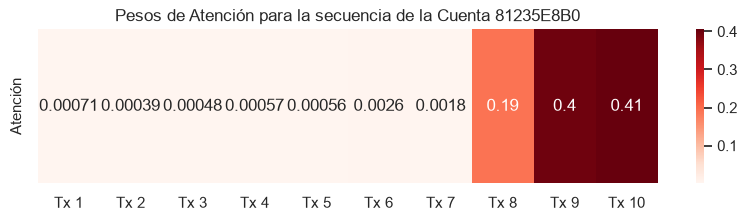

Cuenta: 800604EA0 | Real: Lavado | Predicción Modelo: 96.72% probabilidad de lavado


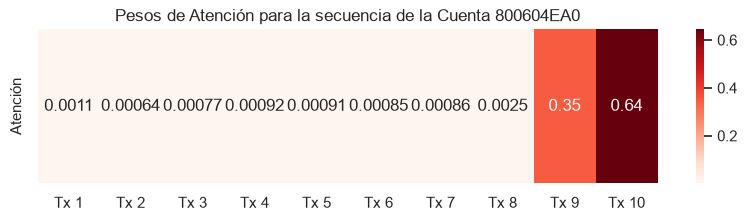

Cuenta: 8066CE920 | Real: Lavado | Predicción Modelo: 80.22% probabilidad de lavado


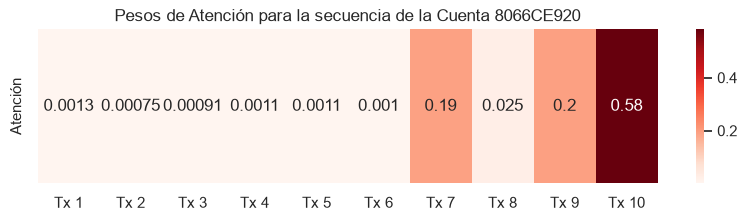

Cuenta: 80189D920 | Real: Lavado | Predicción Modelo: 30.55% probabilidad de lavado


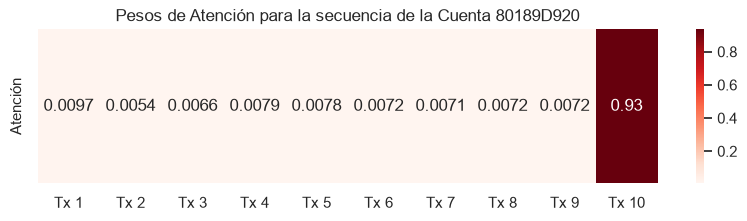

Cuenta: 808942C40 | Real: Lavado | Predicción Modelo: 62.55% probabilidad de lavado


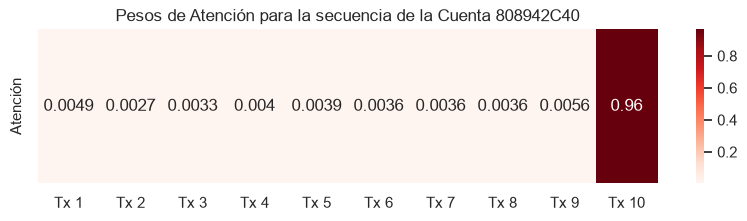

In [17]:
# Extraer casos de prueba
test_seqs = sequences[test_idx_B]
test_labels = labels[test_idx_B]
test_accounts = accounts[test_idx_B]

# Tomar 5 casos positivos (lavado) al azar para ver si el modelo los detectó (Verdaderos Positivos o Falsos Negativos)
positive_indices = np.where(test_labels == 1)[0][:5]

model_B.eval()
with torch.no_grad():
    for idx in positive_indices:
        seq = torch.FloatTensor(test_seqs[idx]).unsqueeze(0).to(device)
        logits, attn = model_B(seq)
        prob = torch.sigmoid(logits).item()
        attn_weights = attn.squeeze().cpu().numpy()
        
        print(f"Cuenta: {test_accounts[idx]} | Real: Lavado | Predicción Modelo: {prob:.2%} probabilidad de lavado")
        
        # Graficar mapa de calor de atención para las MAX_SEQ_LEN transacciones
        plt.figure(figsize=(10, 2))
        sns.heatmap(attn_weights.reshape(1, -1), annot=True, cmap='Reds', xticklabels=[f'Tx {i+1}' for i in range(MAX_SEQ_LEN)], yticklabels=['Atención'])
        plt.title(f'Pesos de Atención para la secuencia de la Cuenta {test_accounts[idx]}')
        plt.show()